# Problem 5.3 — Anomaly Detection with VAE

This notebook uses a Variational Autoencoder for unsupervised anomaly detection on the Kaggle credit card fraud dataset. The core idea is to train the VAE only on normal (non-fraud) transactions, so it learns to reconstruct normal behavior well; fraudulent transactions, never seen during training, are reconstructed poorly, so the per-sample reconstruction error serves as an anomaly score. After loading the data, dropping the Time column, splitting it so the training set contains only normal samples (the test set holds the remaining normals plus all frauds), and standardizing the features, the VAE is built with an MSE reconstruction loss and a linear decoder output (no sigmoid, since the scaled features are continuous and unbounded). The trained model scores the test set by reconstruction error, and these scores are compared against two classical unsupervised detectors — Isolation Forest and One-Class SVM — both also trained on normal data only. All three methods are evaluated with ROC curves and precision-recall curves. Because the dataset is extremely imbalanced (roughly 0.17% fraud), the precision-recall curve gives a more honest picture of real detection performance than ROC-AUC, which tends to look optimistic under heavy imbalance.

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [15]:
df = pd.read_csv("data/creditcard.csv")

df = df.drop(columns=["Time"])

X = df.drop(columns=["Class"]).values
y = df["Class"].values

X_normal = X[y == 0]
X_fraud  = X[y == 1]

X_train_normal, X_test_normal = train_test_split(
    X_normal, test_size=0.2, random_state=42
)

X_test = np.vstack([X_test_normal, X_fraud])
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_fraud))
])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_normal)
X_test  = scaler.transform(X_test)

print("Train (normal only):", X_train.shape)
print("Test (normal + fraud):", X_test.shape)
print("Test frauds:", int(y_test.sum()), "| Test normals:", int((y_test == 0).sum()))

Train (normal only): (227452, 29)
Test (normal + fraud): (57355, 29)
Test frauds: 492 | Test normals: 56863


In [16]:
df_full = pd.read_csv("data/creditcard.csv")

print("Full dataset shape:", df_full.shape)
print("\nClass distribution:")
counts = df_full["Class"].value_counts()
print(f"  Normal (0): {counts[0]:,}  ({counts[0]/len(df_full)*100:.2f}%)")
print(f"  Fraud  (1): {counts[1]:,}  ({counts[1]/len(df_full)*100:.2f}%)")

display(df_full.head())
display(df_full.describe().T[["mean", "std", "min", "max"]])

Full dataset shape: (284807, 31)

Class distribution:
  Normal (0): 284,315  (99.83%)
  Fraud  (1): 492  (0.17%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,mean,std,min,max
Time,9.481386e+04,47488.145955,0.000000,172792.000000
V1,1.168375e-15,1.958696,-56.407510,2.454930
V2,3.416908e-16,1.651309,-72.715728,22.057729
V3,-1.379537e-15,1.516255,-48.325589,9.382558
V4,2.074095e-15,1.415869,-5.683171,16.875344
V5,9.604066e-16,1.380247,-113.743307,34.801666
V6,1.487313e-15,1.332271,-26.160506,73.301626
V7,-5.556467e-16,1.237094,-43.557242,120.589494
V8,1.213481e-16,1.194353,-73.216718,20.007208
V9,-2.406331e-15,1.098632,-13.434066,15.594995


In [17]:
class VAE(nn.Module):
    def __init__(self, input_dim=29, hidden_dim=20, latent_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [18]:
def vae_loss(x_recon, x, mu, logvar):
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    kl_div = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
    return recon_loss + kl_div

In [19]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [20]:
model = VAE(input_dim=29, hidden_dim=20, latent_dim=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 30

train_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(batch)
        loss = vae_loss(x_recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss: {avg_loss:.4f}")

Epoch 5/30 | loss: 21.5596
Epoch 10/30 | loss: 19.8868
Epoch 15/30 | loss: 19.2949
Epoch 20/30 | loss: 19.1323
Epoch 25/30 | loss: 19.0393
Epoch 30/30 | loss: 18.9568


In [21]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    x_recon, mu, logvar = model(X_test_tensor)
    vae_scores = ((X_test_tensor - x_recon) ** 2).mean(dim=1).cpu().numpy()

print("VAE anomaly scores computed for", len(vae_scores), "test samples")
print(f"  mean score (all):    {vae_scores.mean():.4f}")
print(f"  mean score (normal): {vae_scores[y_test == 0].mean():.4f}")
print(f"  mean score (fraud):  {vae_scores[y_test == 1].mean():.4f}")

VAE anomaly scores computed for 57355 test samples
  mean score (all):    0.6862
  mean score (normal): 0.5026
  mean score (fraud):  21.9095


In [22]:
iso = IsolationForest(n_estimators=100, contamination="auto", random_state=42)
iso.fit(X_train)

iso_scores = -iso.score_samples(X_test)
print("Isolation Forest scores computed")
print(f"  mean score (normal): {iso_scores[y_test == 0].mean():.4f}")
print(f"  mean score (fraud):  {iso_scores[y_test == 1].mean():.4f}")

Isolation Forest scores computed
  mean score (normal): 0.3994
  mean score (fraud):  0.5858


In [23]:
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.01)
ocsvm.fit(X_train)

ocsvm_scores = -ocsvm.decision_function(X_test)
print("One-Class SVM scores computed")
print(f"  mean score (normal): {ocsvm_scores[y_test == 0].mean():.4f}")
print(f"  mean score (fraud):  {ocsvm_scores[y_test == 1].mean():.4f}")

One-Class SVM scores computed
  mean score (normal): -4.9038
  mean score (fraud):  2.1339


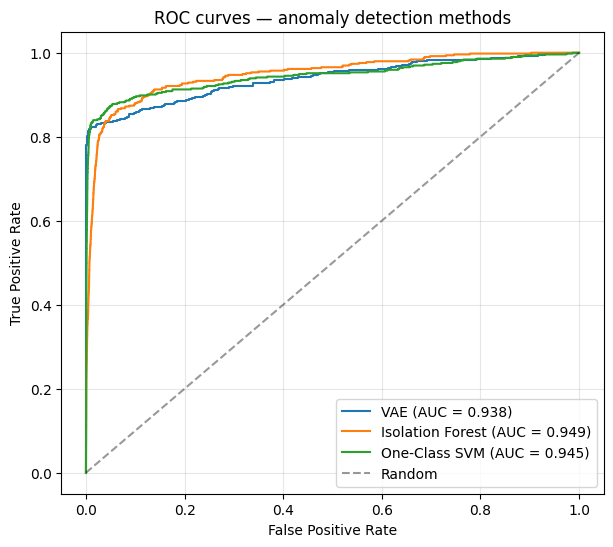

In [24]:
methods = {
    "VAE": vae_scores,
    "Isolation Forest": iso_scores,
    "One-Class SVM": ocsvm_scores,
}

plt.figure(figsize=(7, 6))
for name, scores in methods.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — anomaly detection methods")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

All three methods perform well by ROC, with curves rising steeply toward the top-left and AUC values clustered closely together: Isolation Forest (0.949) and One-Class SVM (0.945) edge slightly ahead of the VAE (0.938). Each method reaches roughly 80% true positive rate at a near-zero false positive rate, meaning it can catch about four out of five frauds before producing meaningful false alarms. All three sit far above the random diagonal, confirming that reconstruction error and the two classical methods all separate fraud from normal transactions effectively.

However, these high ROC-AUC values should be read with caution. Because the test set is so heavily imbalanced (about 0.86% fraud), even a large absolute number of false positives translates into a small false positive rate, which keeps the ROC curves looking optimistic. The precision-recall curve below gives a more honest assessment of how these methods would perform in practice.

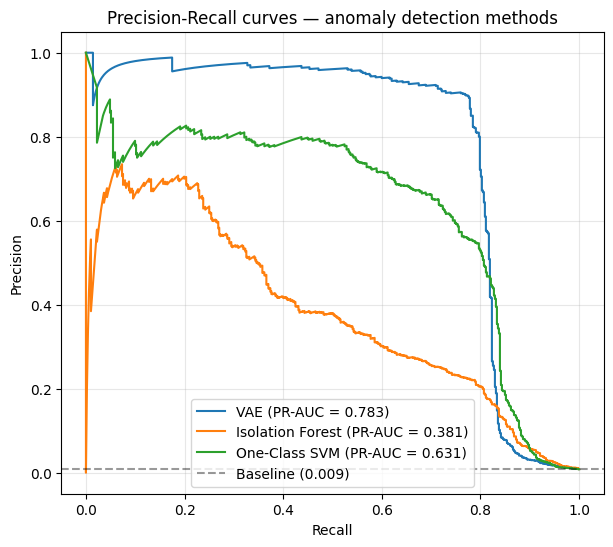

In [25]:
plt.figure(figsize=(7, 6))
for name, scores in methods.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})")

baseline = y_test.mean()
plt.axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves — anomaly detection methods")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The precision-recall curves tell a very different story from ROC, which is precisely why both are needed under heavy class imbalance. The PR-AUC values spread far apart and the ranking inverts: the VAE leads decisively (0.796), One-Class SVM is second (0.631), and Isolation Forest — which had the *highest* ROC-AUC — is now clearly the weakest (0.381). The VAE maintains high precision (around 0.95) across most of the recall range, only dropping off beyond roughly 0.8 recall, meaning it can flag the large majority of frauds while keeping false alarms low. Isolation Forest, by contrast, sacrifices precision quickly as recall increases.

This contrast is the key takeaway. ROC-AUC made all three methods look nearly identical (~0.94) because the enormous number of true normals keeps the false positive rate small even when many false positives occur. Precision-recall ignores the easy true negatives and focuses on how cleanly fraud is separated from the alarms raised, which is what actually matters when frauds are this rare. Judged on the metric that reflects real-world detection quality, the reconstruction-error VAE is the strongest method — and it achieves this fully unsupervised, without ever seeing a labelled fraud during training.